# DSA 210 Project Progress: Data Collection, EDA, and Hypothesis Testing

## Project Topic
This project investigates impulsive purchasing behavior in online shopping environments. It focuses on how the timing of purchases may influence whether a decision is more impulsive or rational.

## Dataset
The dataset used in this project is the Online Retail dataset obtained from Kaggle. It contains transaction-level data including timestamps, product information, quantities, and customer behavior. The dataset consists of several thousand transactions, allowing analysis of purchasing patterns over time.

## Current Work
In this notebook, I:
- loaded and cleaned the dataset,
- created time-based features such as hour and day,
- performed exploratory data analysis (EDA) to understand purchase patterns,
- visualized purchase distribution across hours,
- conducted hypothesis testing to compare purchasing behavior at different times of the day.

## Hypothesis
H0 (Null Hypothesis): There is no significant difference in purchasing behavior between daytime and evening purchases.

H1 (Alternative Hypothesis): There is a significant difference in purchasing behavior between daytime and evening purchases.

## Initial Findings
The analysis shows that purchases are concentrated during certain hours of the day. However, the hypothesis test results indicate that there is no strong statistical evidence of a significant difference between daytime and evening purchasing behavior.

In [4]:
import pandas as pd
df = pd.read_csv("OnlineRetail.csv", encoding="ISO-8859-1", on_bad_lines="skip")
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6.0,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8.0,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6.0,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [5]:
## Data Cleaning
df = df.dropna()
df = df[df['Quantity'] > 0]
df = df[df['UnitPrice'] > 0]

df.shape

(8848, 8)

In [6]:
## Feature Engineering
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])
df['hour'] = df['InvoiceDate'].dt.hour
df['day'] = df['InvoiceDate'].dt.day_name()

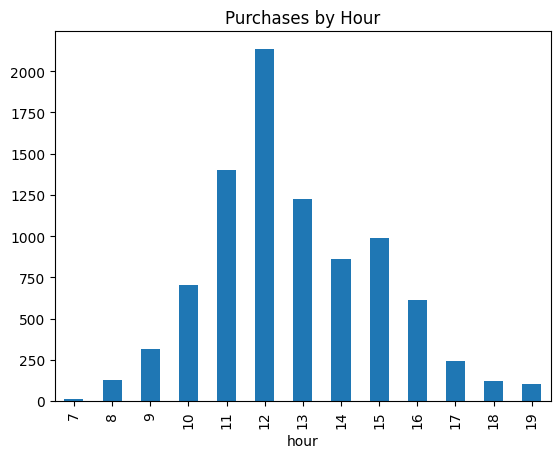

In [7]:
## Exploratory Data Analysis
import matplotlib.pyplot as plt
df['hour'].value_counts().sort_index().plot(kind='bar')
plt.title("Purchases by Hour")
plt.show()

Purchases are concentrated in certain hours, suggesting possible impulsive buying patterns.

In [8]:
## Hypothesis Testing
from scipy.stats import ttest_ind
night = df[df['hour'] >= 18]['Quantity']
day = df[df['hour'] < 18]['Quantity']
ttest_ind(night, day)

TtestResult(statistic=np.float64(-0.6354225103401773), pvalue=np.float64(0.5251693270041955), df=np.float64(8846.0))

This test compares evening and daytime purchases. If a significant difference is observed, it may indicate differences in purchasing behavior related to time.

The p-value is relatively high, suggesting that there is no strong statistical evidence of a difference between evening and daytime purchases.

# Machine Learning Methods

In this section, I apply machine learning methods to classify purchases as impulsive or non-impulsive using the features created from the online retail dataset.

In [9]:
# Create an impulsive purchase proxy
# A purchase is labeled as impulsive if it happens in the evening and has quantity greater than 5.
df['impulsive'] = ((df['hour'] >= 18) & (df['Quantity'] > 5)).astype(int)
df[['hour', 'Quantity', 'UnitPrice', 'impulsive']].head()

,hour,Quantity,UnitPrice,impulsive
0,8,6.0,2.55,0
1,8,6.0,3.39,0
2,8,8.0,2.75,0
3,8,6.0,3.39,0
4,8,6.0,3.39,0


## Feature Selection

I use hour, quantity, and unit price as input features to predict whether a purchase can be classified as impulsive.

In [10]:
X = df[['hour', 'Quantity', 'UnitPrice']]
y = df['impulsive']
X.head()

,hour,Quantity,UnitPrice
0,8,6.0,2.55
1,8,6.0,3.39
2,8,8.0,2.75
3,8,6.0,3.39
4,8,6.0,3.39


## Train-Test Split

The data is divided into training and testing sets so that the model can be evaluated on unseen data.

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Logistic Regression Model

In [12]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

## Model Evaluation

In [13]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = log_model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Accuracy: 0.9887005649717514

Classification Report:
              precision    recall  f1-score   support

           0       0.99      1.00      0.99      1757
           1       0.00      0.00      0.00        13

    accuracy                           0.99      1770
   macro avg       0.50      0.50      0.50      1770
weighted avg       0.99      0.99      0.99      1770


Confusion Matrix:
[[1750    7]
 [  13    0]]


## ML Interpretation

The logistic regression model was used to classify purchases as impulsive or non-impulsive based on hour, quantity, and unit price. Since impulsiveness is not directly provided in the dataset, it was approximated using a rule-based proxy. The model results give an initial idea of whether transaction-level features can help predict impulsive purchasing behavior.

In [14]:
!git clone https://github.com/cahidekaya/Dsa210-Project.git

Cloning into 'Dsa210-Project'...
remote: Enumerating objects: 31, done.
remote: Counting objects: 100% (31/31), done.
remote: Compressing objects: 100% (19/19), done.
remote: Total 31 (delta 12), reused 26 (delta 10), pack-reused 0 (from 0)
Receiving objects: 100% (31/31), 89.24 KiB | 7.44 MiB/s, done.
Resolving deltas: 100% (12/12), done.


In [15]:
%cd Dsa210-Project

/content/Dsa210-Project


In [16]:
!git tag milestone1
!git push origin milestone1

fatal: tag 'milestone1' already exists
fatal: could not read Username for 'https://github.com': No such device or address
